In [7]:
# 📌 Step 1: Imports & GPU/CPU Setup
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [8]:
# 📌 Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Using GPU: {len(gpus)} device(s) available.")
    except RuntimeError as e:
        print(f"⚠️ GPU configuration error: {e}")
else:
    print("⚙️ Using CPU: No GPU found.")

⚙️ Using CPU: No GPU found.


In [ ]:
# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
NUM_CLASSES = 4
TRAIN_DIR = "../dataset/train"
VAL_DIR = "../dataset/test"
MODEL_SAVE_PATH = "models/VGG16_model.keras"

In [ ]:
# 📌 Data Preprocessing & Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 3209 images belonging to 4 classes.
Found 880 images belonging to 4 classes.


In [ ]:
# 📌 Build VGG16 Transfer Learning Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
# 📌 Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True)

In [ ]:
# 📌 Train Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 497s 5s/step - accuracy: 0.3339 - loss: 1.4584 - val_accuracy: 0.6080 - val_loss: 1.3595
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 416s 4s/step - accuracy: 0.5694 - loss: 1.0610 - val_accuracy: 0.6739 - val_loss: 1.1578
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - accuracy: 0.6548 - loss: 0.9068 - val_accuracy: 0.6625 - val_loss: 1.0297
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 301s 3s/step - accuracy: 0.7298 - loss: 0.7670 - val_accuracy: 0.6795 - val_loss: 0.8766
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 311s 3s/step - accuracy: 0.7686 - loss: 0.6650 - val_accuracy: 0.6830 - val_loss: 0.7931


In [18]:
model.save(MODEL_SAVE_PATH)  # Saving the model after training

print(f"✅ Model saved successfully at {MODEL_SAVE_PATH}")

✅ Model saved successfully at models/VGG16_model.keras


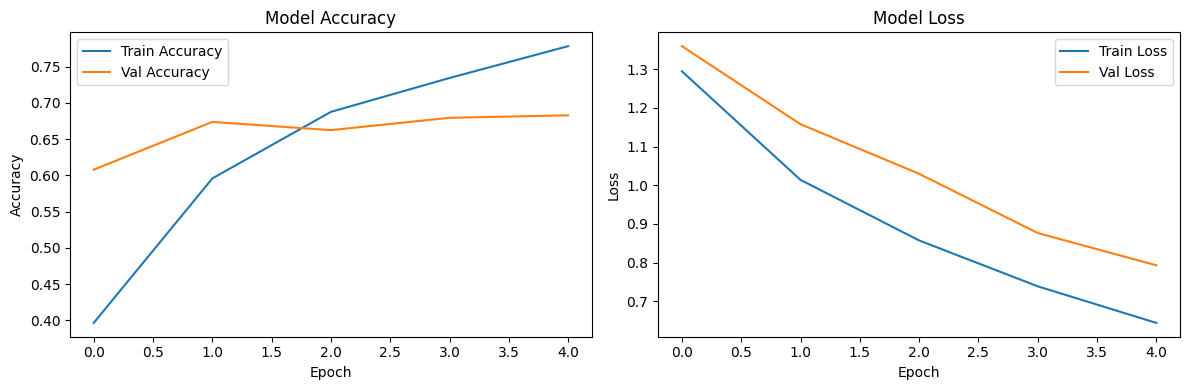

In [19]:
# 📌 Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()